# Project 1: Predicting Minnesota Housing Prices

**Dataset:** Synthetic Minnesota Housing Data  
**Goal:** Predict median house values using demographic and geographic features


In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_housing_data(csv_path="data/housing_data.csv"):
    return pd.read_csv(csv_path)

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-93.210894,48.066341,51,2915,527.160504,1068,731,3.506922,291847
1,-94.477019,46.089383,105,8170,893.652474,5706,2727,6.733504,358247
2,-96.622070,48.565728,58,6890,689.000000,2462,1229,3.865865,265453
3,-89.569516,47.614471,56,14087,1960.620662,4244,1931,3.056389,219226
4,-95.854242,44.055646,102,16225,2803.532533,8865,3189,1.738006,68446


## Exploratory Data Analysis (EDA)


In [215]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12000 non-null  float64
 1   latitude            12000 non-null  float64
 2   housing_median_age  12000 non-null  int64  
 3   total_rooms         12000 non-null  int64  
 4   total_bedrooms      11089 non-null  float64
 5   population          12000 non-null  int64  
 6   households          12000 non-null  int64  
 7   median_income       12000 non-null  float64
 8   median_house_value  12000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 843.9 KB


In [216]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,12000.000000,12000.000000,12000.000000,12000.000000,11089.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,-93.324047,46.436738,60.019417,9355.550417,1865.445771,4673.297583,1799.506167,3.314479,236412.630250
std,2.226219,1.699742,34.317646,5920.198632,1302.557383,2813.882318,975.274962,1.594762,107247.106911
min,-97.199852,43.500078,1.000000,245.000000,41.791234,150.000000,100.000000,0.522221,30000.000000
25%,-95.250541,44.951779,30.000000,4512.750000,838.539355,2343.500000,958.000000,2.205966,161080.750000
50%,-93.295870,46.443675,60.000000,8549.000000,1613.038525,4418.000000,1788.500000,2.978441,217512.000000
75%,-91.384273,47.901535,90.000000,13415.250000,2636.236666,6683.000000,2641.000000,4.053849,290211.750000
max,-89.500135,49.399864,119.000000,35253.000000,8707.371461,14769.000000,3499.000000,15.000000,650000.000000


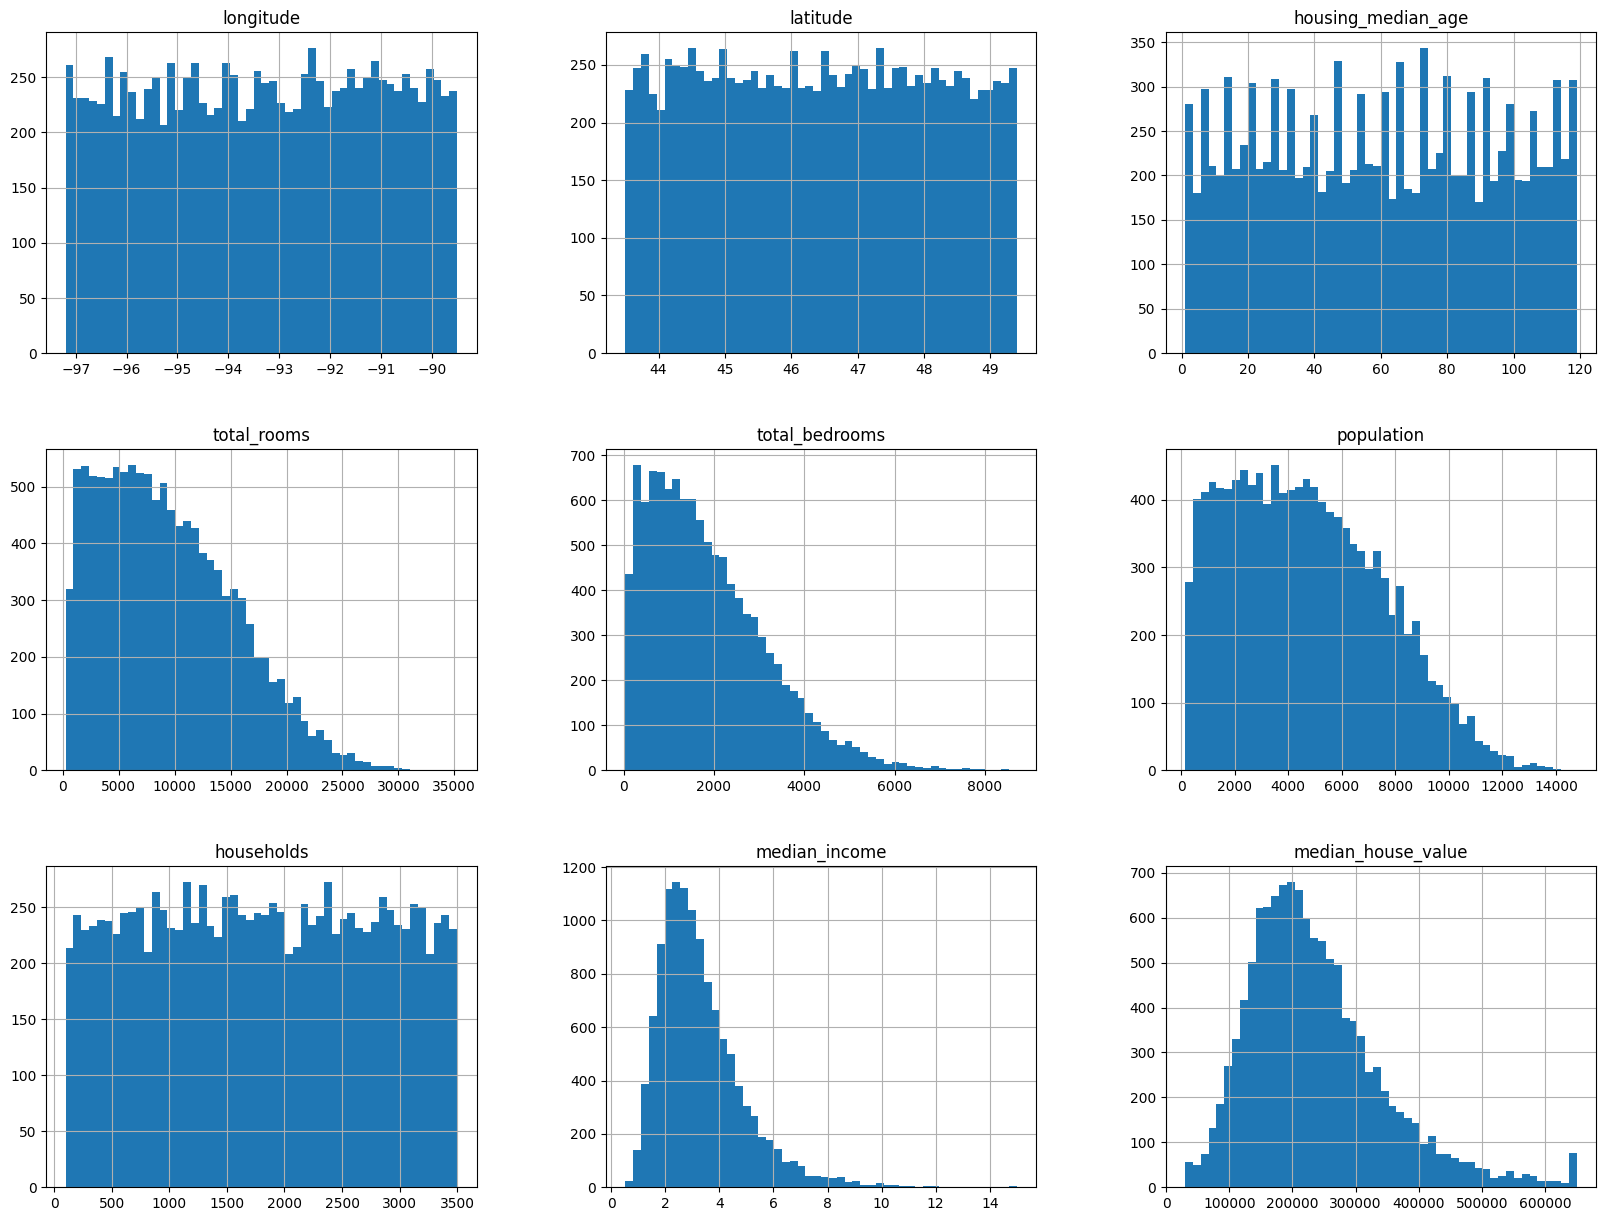

In [217]:
housing.hist(bins=50, figsize=(20, 15))
plt.show()

In [218]:
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.936791
latitude              0.012223
longitude             0.010525
households            0.006917
total_rooms           0.002976
population            0.000726
total_bedrooms       -0.000535
housing_median_age   -0.105493
Name: median_house_value, dtype: float64

<Axes: xlabel='median_income', ylabel='median_house_value'>

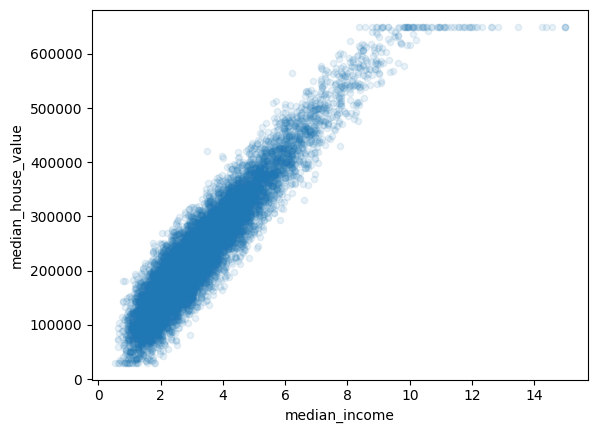

In [219]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

## Creating a Stratified Train/Test Split

<Axes: >

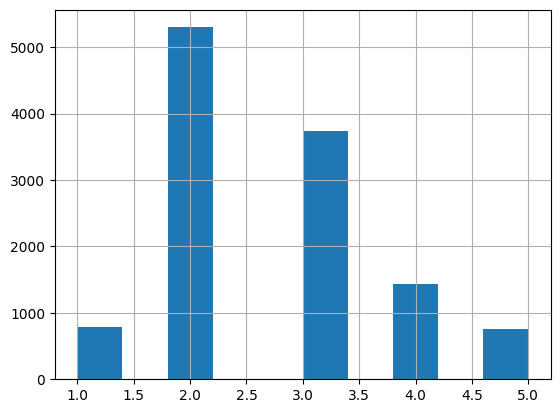

In [220]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# Create income categories
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

housing["income_cat"].hist()

In [221]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [222]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Preparing Data for Machine Learning

In [223]:
housing = strat_train_set.copy()

housing_labels = housing["median_house_value"].copy()
housing = housing.drop("median_house_value", axis=1)

In [224]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

## Data Preprocessing Pipeline

In [225]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

class AddCombinedAttributes(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()

        households = X_["households"].replace(0, np.nan)
        total_rooms = X_["total_rooms"].replace(0, np.nan)

        X_["rooms_per_household"] = X_["total_rooms"] / households
        X_["bedrooms_per_room"] = X_["total_bedrooms"] / total_rooms
        X_["population_per_household"] = X_["population"] / households

        return X_

preprocess_pipeline = Pipeline([
    ("feat_eng", AddCombinedAttributes()),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Model Training

In [226]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Raw train data
X_train = strat_train_set.drop("median_house_value", axis=1).copy()
y_train = strat_train_set["median_house_value"].copy()

def rmse_cv(model_pipeline, X, y, cv=10):
    scores = cross_val_score(model_pipeline, X, y, scoring="neg_mean_squared_error", cv=cv)
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean(), rmse_scores.std()

# ---- Linear Regression ----
lin_model = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("model", LinearRegression())
])
lin_model.fit(X_train, y_train)
lin_preds = lin_model.predict(X_train)
lin_rmse = np.sqrt(mean_squared_error(y_train, lin_preds))
print("Linear Regression RMSE (train):", lin_rmse)

# ---- Decision Tree ----
tree_model = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("model", DecisionTreeRegressor(random_state=42))
])
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_train)
tree_rmse = np.sqrt(mean_squared_error(y_train, tree_preds))
print("Decision Tree RMSE (train):", tree_rmse)

tree_cv_mean, tree_cv_std = rmse_cv(tree_model, X_train, y_train, cv=10)
print("Decision Tree CV RMSE Mean:", tree_cv_mean)
print("Decision Tree CV RMSE Std:", tree_cv_std)

# ---- Random Forest ----
forest_model = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("model", RandomForestRegressor(random_state=42))
])
forest_model.fit(X_train, y_train)
forest_preds = forest_model.predict(X_train)
forest_rmse = np.sqrt(mean_squared_error(y_train, forest_preds))
print("Random Forest RMSE (train):", forest_rmse)

forest_cv_mean, forest_cv_std = rmse_cv(forest_model, X_train, y_train, cv=10)
print("Random Forest CV RMSE Mean:", forest_cv_mean)
print("Random Forest CV RMSE Std:", forest_cv_std)

Linear Regression RMSE (train): 35855.62157485616
Decision Tree RMSE (train): 0.0
Decision Tree CV RMSE Mean: 50742.23102394011
Decision Tree CV RMSE Std: 833.6783023058299
Random Forest RMSE (train): 13498.253617515458
Random Forest CV RMSE Mean: 36216.02649544348
Random Forest CV RMSE Std: 1056.8594530295823


## Hyperparameter Tuning with GridSearchCV

In [227]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Raw train/test data
X_train = strat_train_set.drop("median_house_value", axis=1).copy()
y_train = strat_train_set["median_house_value"].copy()

X_test = strat_test_set.drop("median_house_value", axis=1).copy()
y_test = strat_test_set["median_house_value"].copy()

# Pipeline to tune (preprocess + model)
tune_pipeline = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = [
    {"model__n_estimators": [50, 100, 150], "model__max_features": [4, 6, 8]},
    {"model__bootstrap": [False], "model__n_estimators": [50, 100], "model__max_features": [4, 6]},
]

grid_search = GridSearchCV(
    tune_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

final_model = grid_search.best_estimator_  # full pipeline
final_predictions = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print("Final Test RMSE (Tuned Pipeline):", final_rmse)


Best Params: {'model__max_features': 6, 'model__n_estimators': 150}
Final Test RMSE (Tuned Pipeline): 35967.03661618074


## Model Evaluation Summary

Linear Regression produced an RMSE of about 35.9k on the training set, providing a baseline performance.
A Decision Tree achieved zero training error but performed poorly under cross-validation (CV RMSE ≈ 50.8k),
indicating severe overfitting. A Random Forest reduced variance and improved generalization, achieving a
CV RMSE ≈ 36.2k and a final test RMSE ≈ 36.0k. Since the test RMSE closely matches the CV estimate,
the tuned Random Forest model is selected as the final model.

In [228]:
import pandas as pd

rf_model = final_model.named_steps["model"]

feature_names = final_model.named_steps["preprocess"] \
    .named_steps["feat_eng"] \
    .transform(X_train).columns

importances = rf_model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi.sort_values("importance", ascending=False).head(10)


,feature,importance
7,median_income,0.887534
2,housing_median_age,0.020850
1,latitude,0.012184
0,longitude,0.011973
10,population_per_household,0.011156
9,bedrooms_per_room,0.010792
8,rooms_per_household,0.010538
5,population,0.008826
6,households,0.008767
4,total_bedrooms,0.008738


## Feature Importance Analysis

The Random Forest model identified `median_income` as the most influential predictor,
accounting for nearly 89% of the total feature importance. This aligns with economic
intuition, as income strongly correlates with property values.

Geographic features (latitude and longitude) and housing age contributed modestly
to predictive performance. Engineered density features such as
`rooms_per_household`, `bedrooms_per_room`, and `population_per_household`
also provided additional predictive signal, confirming the value of feature engineering.